# Классификация видов деревьев на основе массивов точек LiDAR с применением нейронных сетей (RandomForest, PointNet++)

**Этапы работы программы:**
1. Предобработка сырых файлов `.las`
2. Выделение независимой тестовой выборки
3. Создание и обучение нейросетей RandomForest, PointNet++
4. Оценка моделей

In [1]:
import os
import glob
import random
import shutil
import numpy as np
import laspy
import torch
import torch.nn.functional as F
from torch.utils.data import random_split
from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader
from torch_geometric.nn import PointNetConv, global_max_pool, fps, radius
from torch.nn import Sequential, Linear, ReLU, BatchNorm1d, Dropout
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
import warnings
import seaborn as sns
warnings.filterwarnings('ignore')

In [2]:
DATASET_DIR = "./"
HOLDOUT_DIR = "holdout_test_data"
HOLDOUT_COUNT = 4

NUM_POINTS = 2048
GROUND_THRESHOLD = 0.4

OUT_POINTS_FILE = "dataset_points.npy"
OUT_LABELS_FILE = "dataset_labels.npy"
OUT_CLASSES_FILE = "class_mapping.npy"

In [3]:
import torch
print("PyTorch version:", torch.__version__)
print("CUDA version:", torch.version.cuda)

PyTorch version: 2.8.0+cpu
CUDA version: None


#### Общая предобработка данных
Предобработка файлов `.las` для всех моделей

In [4]:
def process_point_cloud(filepath):
    try:
        las = laspy.read(filepath)
        points = np.vstack((las.x, las.y, las.z)).transpose()
        if len(points) == 0: return None

        z_min = np.min(points[:, 2])
        mask = points[:, 2] > (z_min + GROUND_THRESHOLD)
        points = points[mask]
        if len(points) == 0: return None
        
        current_num_points = points.shape[0]
        if current_num_points >= NUM_POINTS:
            indices = np.random.choice(current_num_points, NUM_POINTS, replace=False)
        else:
            indices = np.random.choice(current_num_points, NUM_POINTS, replace=True)
        points = points[indices]

        centroid = np.mean(points, axis=0)
        points -= centroid
        max_distance = np.max(np.sqrt(np.sum(points**2, axis=1)))
        if max_distance > 0: points /= max_distance
        
        return points.astype(np.float32)
    except Exception as e:
        return None

files_exist = os.path.exists(OUT_POINTS_FILE) and os.path.exists(OUT_LABELS_FILE)

if files_exist:
    print(f"Готовые файлы датасета ({OUT_POINTS_FILE}) уже существуют.")
else:
    print("Начинаем предобработку .las файлов...")
    
    # Ищем папки с классами
    class_names = [d for d in os.listdir(DATASET_DIR) 
                   if os.path.isdir(os.path.join(DATASET_DIR, d)) 
                   and not d.startswith('.') 
                   and d != HOLDOUT_DIR]
    class_names.sort() 
    class_to_idx = {name: idx for idx, name in enumerate(class_names)}

    all_points, all_labels = [], []
    total_train = 0

    for class_name in class_names:
        class_dir = os.path.join(DATASET_DIR, class_name)
        las_files = glob.glob(os.path.join(class_dir, "*.las")) + glob.glob(os.path.join(class_dir, "*.LAS"))
        
        # обрабатываем все найденные файлы в папке класса
        for filepath in las_files:
            pts = process_point_cloud(filepath)
            if pts is not None:
                all_points.append(pts)
                all_labels.append(class_to_idx[class_name])
                total_train += 1

    X = np.array(all_points, dtype=np.float32)
    y = np.array(all_labels, dtype=np.int64)

    np.save(OUT_POINTS_FILE, X)
    np.save(OUT_LABELS_FILE, y)
    np.save(OUT_CLASSES_FILE, class_names)

    print(f"\nПредобработка завершена!")
    print(f"Использовано для датасета: {total_train} файлов.")

Готовые файлы датасета (dataset_points.npy) уже существуют.


#### Визуализация предобработанных данных
Здесь можно посмотреть, как именно выглядят наши деревья после предобработки

In [5]:
from IPython.display import display, clear_output

raw_files = []

for class_name in os.listdir(DATASET_DIR):
    class_dir = os.path.join(DATASET_DIR, class_name)
    if os.path.isdir(class_dir) and class_name != HOLDOUT_DIR and not class_name.startswith('.'):
        files = glob.glob(os.path.join(class_dir, "*.las")) + glob.glob(os.path.join(class_dir, "*.LAS"))
        for f in files:
            raw_files.append((f"Train: {class_name} / {os.path.basename(f)}", f))

if os.path.exists(HOLDOUT_DIR):
    for class_name in os.listdir(HOLDOUT_DIR):
        class_dir = os.path.join(HOLDOUT_DIR, class_name)
        if os.path.isdir(class_dir):
            files = glob.glob(os.path.join(class_dir, "*.las")) + glob.glob(os.path.join(class_dir, "*.LAS"))
            for f in files:
                raw_files.append((f"Holdout: {class_name} / {os.path.basename(f)}", f))

available_files = list(set(raw_files))
available_files.sort()

# 2. Функция отрисовки До/После
def plot_before_after(filepath):
    if not filepath: return
    
    # --- ПОЛУЧАЕМ СЫРЫЕ ДАННЫЕ ---
    try:
        las = laspy.read(filepath)
        raw_points = np.vstack((las.x, las.y, las.z)).transpose()
        original_point_count = len(raw_points)
    except:
        print("❌ Ошибка чтения сырого файла.")
        return

    # ЗАЩИТА ОТ ЗАВИСАНИЯ: Если сырых точек слишком много, берем случайные 10 000 для картинки
    VIZ_LIMIT = 50000
    if len(raw_points) > VIZ_LIMIT:
        idx = np.random.choice(len(raw_points), VIZ_LIMIT, replace=False)
        raw_points_viz = raw_points[idx]
    else:
        raw_points_viz = raw_points

    # --- ПОЛУЧАЕМ ОБРАБОТАННЫЕ ДАННЫЕ (из нашей функции) ---
    processed_points = process_point_cloud(filepath)
    if processed_points is None:
        print("❌ Файл оказался пустым после удаления земли.")
        return

    # Создаем большое полотно: 2 строки, 4 столбца
    fig = plt.figure(figsize=(20, 11))
    fig.suptitle(f"Файл: {os.path.basename(filepath)}", fontsize=18, fontweight='bold', y=0.98)

    views = [
        (0, -90, "Спереди"),
        (0, 0, "Сбоку"),
        (90, -90, "Сверху"),
        (15, -45, "Изометрия")
    ]

    # ================= ВЕРХНИЙ РЯД: СЫРОЕ ОБЛАКО =================
    rx, ry, rz = raw_points_viz[:, 0], raw_points_viz[:, 1], raw_points_viz[:, 2]
    
    # Кадрирование для сырого облака
    r_max_range = np.array([rx.max()-rx.min(), ry.max()-ry.min(), rz.max()-rz.min()]).max() / 2.0
    r_mid_x = (rx.max()+rx.min()) * 0.5
    r_mid_y = (ry.max()+ry.min()) * 0.5
    r_mid_z = (rz.max()+rz.min()) * 0.5

    for i, (elev, azim, title) in enumerate(views):
        ax = fig.add_subplot(2, 4, i+1, projection='3d')
        ax.scatter(rx, ry, rz, c=rz, cmap='terrain', s=2, alpha=0.5, marker='o', edgecolors='none')
        ax.view_init(elev=elev, azim=azim)
        
        # Подписываем только первый график в ряду
        if i == 0:
            ax.set_title(f"ДО ОБРАБОТКИ (Земля + Шумы)\nВсего точек: {original_point_count}\n\n{title}", fontsize=14)
        else:
            ax.set_title(f"\n\n\n{title}", fontsize=14)
            
        ax.set_xlim(r_mid_x - r_max_range, r_mid_x + r_max_range)
        ax.set_ylim(r_mid_y - r_max_range, r_mid_y + r_max_range)
        ax.set_zlim(r_mid_z - r_max_range, r_mid_z + r_max_range)
        ax.axis('off')

    # ================= НИЖНИЙ РЯД: ПОСЛЕ ПРЕДОБРАБОТКИ =================
    px, py, pz = processed_points[:, 0], processed_points[:, 1], processed_points[:, 2]
    
    # Кадрирование для обработанного облака
    p_max_range = np.array([px.max()-px.min(), py.max()-py.min(), pz.max()-pz.min()]).max() / 2.0
    p_mid_x = (px.max()+px.min()) * 0.5
    p_mid_y = (py.max()+py.min()) * 0.5
    p_mid_z = (pz.max()+pz.min()) * 0.5

    for i, (elev, azim, title) in enumerate(views):
        ax = fig.add_subplot(2, 4, i+5, projection='3d') # Индекс i+5 переносит нас на нижний ряд
        ax.scatter(px, py, pz, c=pz, cmap='jet', s=6, alpha=0.9, marker='o', edgecolors='none')
        ax.view_init(elev=elev, azim=azim)
        
        if i == 0:
            ax.set_title(f"ПОСЛЕ ОБРАБОТКИ (Вход в нейросеть)\nТочек оставлено: 2048\n\n{title}", fontsize=14)
        else:
            ax.set_title(f"\n\n\n{title}", fontsize=14)
            
        ax.set_xlim(p_mid_x - p_max_range, p_mid_x + p_max_range)
        ax.set_ylim(p_mid_y - p_max_range, p_mid_y + p_max_range)
        ax.set_zlim(p_mid_z - p_max_range, p_mid_z + p_max_range)
        ax.axis('off')

    plt.subplots_adjust(wspace=0.05, hspace=0.1)
    plt.show()

# 3. Интерактивный интерфейс
dropdown = widgets.Dropdown(
    options=available_files,
    description='Файл:',
    layout={'width': '500px'}
)

out = widgets.Output()

def on_dropdown_change(change):
    with out:
        clear_output(wait=True)
        plot_before_after(change.new)

dropdown.observe(on_dropdown_change, names='value')
display(dropdown, out)

# Запуск для первого файла по умолчанию
with out:
    plot_before_after(dropdown.value)

Dropdown(description='Файл:', layout=Layout(width='500px'), options=(('Holdout: Alder / alder_03.las', 'holdou…

Output()

# Классическое машинное обучение (Random Forest)
Эта часть кода обучает модель Random Forest

In [6]:
def extract_features_from_cloud(points):
    # Разделяем на координаты
    x_raw = points[:, 0]
    y_raw = points[:, 1]
    z_raw = points[:, 2]
    
    # 1. Обеспечиваем инвариантность к сдвигу (центрируем X и Y)
    # Z обычно оставляем от земли (min z = 0), если данные уже нормализованы по высоте
    x = x_raw - np.mean(x_raw)
    y = y_raw - np.mean(y_raw)
    z = z_raw - np.min(z_raw) # Высота от основания
    
    # Считаем радиус в плоскости XY для каждой точки
    # Это ключевой инвариант к вращению вокруг вертикальной оси (ствола)
    r = np.sqrt(x**2 + y**2)
    
    features = []
    
    # --- Высотные признаки (уже инвариантны к XY вращению) ---
    z_max = np.max(z)
    features.append(z_max) # Максимальная высота
    features.append(np.var(z)) # Разброс по высоте
    features.extend(np.percentile(z, [10, 25, 50, 75, 90])) # Форма профиля высот
    
    # --- Горизонтальные инвариантные признаки (вместо X и Y) ---
    features.append(np.max(r))             # Максимальный радиус кроны
    features.append(np.mean(r))            # Средний радиус
    features.append(np.var(r))             # Разброс плотности кроны от центра
    features.extend(np.percentile(r, [10, 25, 50, 75, 90])) # Распределение биомассы от центра
    
    # --- Плотность по третям высоты (инвариантно) ---
    h33 = z_max * 0.33
    h66 = z_max * 0.66
    n_points = len(z)
    features.extend([
        np.sum(z < h33) / n_points,
        np.sum((z >= h33) & (z < h66)) / n_points,
        np.sum(z >= h66) / n_points
    ])
    
    # --- Геометрические инварианты (PCA) ---
    # Собственные значения ковариационной матрицы не меняются при вращении
    cov_matrix = np.cov(np.stack([x, y, z]), rowvar=True)
    eigenvalues, _ = np.linalg.eigh(cov_matrix)
    eigenvalues = np.sort(eigenvalues)[::-1]
    
    features.extend(eigenvalues) # 3D форма (вытянутость, плоскость, сферичность)
    
    # Дополнительно: Отношение собственных значений (линейность, плантарность)
    # Помогает отличить хвойные (вытянутые вверх) от лиственных (разлапистых)
    features.append(eigenvalues[1] / (eigenvalues[0] + 1e-9))
    
    return np.array(features)

In [7]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import learning_curve
from sklearn.model_selection import StratifiedKFold

In [18]:
print("Загрузка нормализованных точек...")
X_raw = np.load(OUT_POINTS_FILE)
y_rf = np.load(OUT_LABELS_FILE)
class_names = np.load(OUT_CLASSES_FILE)

print("Извлечение геометрических признаков...")
X_features = np.array([extract_features_from_cloud(cloud) for cloud in X_raw])

# Разбитие на обучающую и тренировную выборки (80/20)
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_features, y_rf, test_size=0.2, random_state=40, stratify=y_rf
)

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train_rf, y_train_rf)
print("Бейзлайн accuracy:", dummy.score(X_test_rf, y_test_rf))

print(f"Обучение Random Forest (Train: {len(X_train_rf)}, Test: {len(X_test_rf)})...")
rf_model = RandomForestClassifier(n_estimators=200, random_state=12, n_jobs=-1)
rf_model.fit(X_train_rf, y_train_rf)

# Оценка модели
y_pred_rf = rf_model.predict(X_test_rf)
acc_rf = accuracy_score(y_test_rf, y_pred_rf)

print(f"Точность Random Forest: {acc_rf * 100:.2f}%")
print("\nДетальный отчет по классам:")
print(classification_report(y_test_rf, y_pred_rf, target_names=class_names))

Загрузка нормализованных точек...
Извлечение геометрических признаков...
Бейзлайн accuracy: 0.2534246575342466
Обучение Random Forest (Train: 584, Test: 146)...
Точность Random Forest: 81.51%

Детальный отчет по классам:
              precision    recall  f1-score   support

       Alder       0.86      0.60      0.71        10
       Aspen       0.75      0.64      0.69        28
       Birch       0.77      0.80      0.79        30
         Fir       0.91      0.71      0.80        14
        Pine       0.74      0.93      0.82        27
      Spruce       0.92      0.97      0.95        37

    accuracy                           0.82       146
   macro avg       0.82      0.78      0.79       146
weighted avg       0.82      0.82      0.81       146



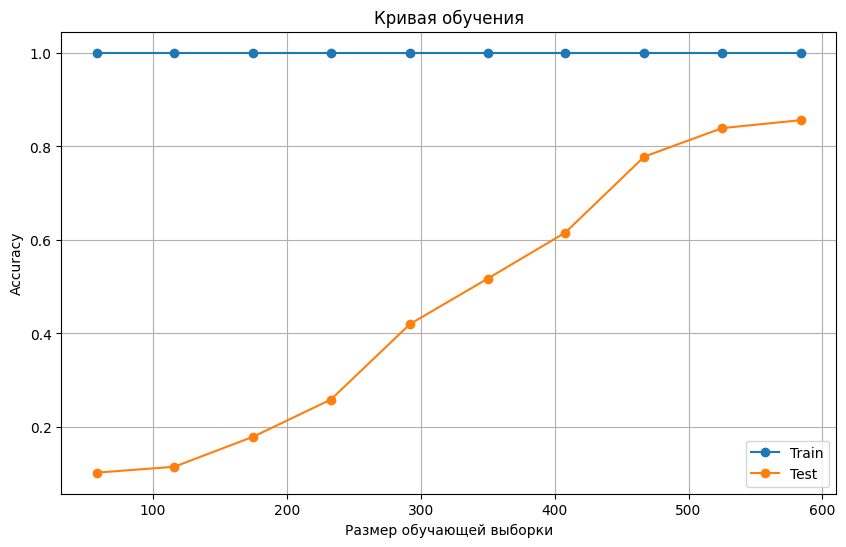

In [9]:
cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_sizes, train_scores, test_scores = learning_curve(
    rf_model, X_features, y_rf, cv=cv_splitter, scoring='f1_macro', 
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Train')
plt.plot(train_sizes, test_scores.mean(axis=1), 'o-', label='Test')
plt.xlabel('Размер обучающей выборки')
plt.ylabel('Accuracy')
plt.title('Кривая обучения')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
import pandas as pd
pd.DataFrame(X_features)

,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
0,1.336640,0.100154,0.466622,0.909534,1.133045,1.225516,1.277838,0.161499,0.052833,0.001155,...,0.045847,0.071501,0.106475,0.097168,0.137207,0.765625,0.100288,0.002870,0.000993,0.028615
1,1.230229,0.034642,0.750937,0.921821,1.021900,1.160786,1.197550,0.244459,0.098544,0.002051,...,0.100443,0.129577,0.154068,0.013672,0.115234,0.871094,0.035080,0.006689,0.004657,0.190688
2,1.636410,0.212804,0.248639,0.616434,1.115301,1.396509,1.476741,0.107165,0.032574,0.000476,...,0.026193,0.042617,0.070338,0.232422,0.250000,0.517578,0.213539,0.000550,0.000357,0.002576
3,1.212518,0.035090,0.707263,0.902346,1.049949,1.147373,1.182587,0.195939,0.084877,0.001802,...,0.081761,0.113032,0.146326,0.009766,0.148438,0.841797,0.036072,0.005735,0.002310,0.158997
4,1.269223,0.097630,0.505902,0.821122,1.148260,1.235854,1.245984,0.091573,0.028050,0.000357,...,0.022868,0.041768,0.055666,0.084961,0.182617,0.732422,0.097915,0.000593,0.000314,0.006059
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,1.384125,0.074810,0.615469,0.896311,1.053923,1.174430,1.265865,0.150147,0.054343,0.000667,...,0.050225,0.069201,0.091110,0.042480,0.225098,0.732422,0.075627,0.001822,0.001019,0.024091
726,1.403295,0.038024,0.729653,0.843176,0.982306,1.135230,1.259127,0.145146,0.043383,0.000865,...,0.036996,0.060425,0.083424,0.005371,0.361328,0.633301,0.038094,0.002051,0.000646,0.053834
727,1.339509,0.037088,0.742144,0.891181,1.034135,1.133291,1.235670,0.155703,0.073622,0.001250,...,0.072937,0.102688,0.119972,0.010254,0.208984,0.780762,0.037297,0.003502,0.002980,0.093883
728,1.499616,0.063067,0.617774,0.841557,1.044036,1.162853,1.267819,0.207941,0.100263,0.002081,...,0.102546,0.135369,0.158164,0.032715,0.380859,0.586426,0.063326,0.006417,0.005495,0.101329


#### Интерактивная проверка Random Forest
Предпросмотр работы RandomForest

In [11]:
import ipywidgets as widgets
from IPython.display import display, clear_output

raw_files = []

for class_name in os.listdir(DATASET_DIR):
    class_dir = os.path.join(DATASET_DIR, class_name)
    if os.path.isdir(class_dir) and class_name != HOLDOUT_DIR and not class_name.startswith('.'):
        files = glob.glob(os.path.join(class_dir, "*.las")) + glob.glob(os.path.join(class_dir, "*.LAS"))
        for f in files:
            raw_files.append((f"Train: {class_name} / {os.path.basename(f)}", f))

if os.path.exists(HOLDOUT_DIR):
    for class_name in os.listdir(HOLDOUT_DIR):
        class_dir = os.path.join(HOLDOUT_DIR, class_name)
        if os.path.isdir(class_dir):
            files = glob.glob(os.path.join(class_dir, "*.las")) + glob.glob(os.path.join(class_dir, "*.LAS"))
            for f in files:
                raw_files.append((f"Holdout: {class_name} / {os.path.basename(f)}", f))

available_files = list(set(raw_files))
available_files.sort()

def interactive_rf_prediction(filepath):
    if not filepath:
        return
        
    print(f"Обработка файла: {os.path.basename(filepath)}...")
    
    points = process_point_cloud(filepath)

    features = extract_features_from_cloud(points)
    features_2d = features.reshape(1, -1)
    
    pred_idx = rf_model.predict(features_2d)[0]
    probabilities = rf_model.predict_proba(features_2d)[0]
    
    predicted_class = class_names[pred_idx]
    confidence = probabilities[pred_idx] * 100
    
    print(" Результаты Random Forest")
    print(f"➤ Ответ модели:  {predicted_class.upper()}")
    print(f"➤ Уверенность:   {confidence:.1f}%\n")
    
    print("Вероятности :")
    top_indices = np.argsort(probabilities)[::-1]
    for i in range(min(5, len(class_names))):
        idx = top_indices[i]
        print(f"   {i+1}. {class_names[idx]:<10} - {probabilities[idx]*100:>5.1f}%")

dropdown_rf = widgets.Dropdown(
    options=available_files,
    description='Файл:',
    layout={'width': '400px'}
)

output_rf = widgets.Output()

def on_dropdown_change(change):
    with output_rf:
        clear_output(wait=True)
        interactive_rf_prediction(change.new)

dropdown_rf.observe(on_dropdown_change, names='value')
display(dropdown_rf, output_rf)

with output_rf:
    interactive_rf_prediction(dropdown_rf.value)

Dropdown(description='Файл:', layout=Layout(width='400px'), options=(('Holdout: Alder / alder_03.las', 'holdou…

Output()

# Глубокое машинное обучение (PointNet++)

Эта часть кода обучает модель PointNet++

In [12]:
BATCH_SIZE = 16
EPOCHS = 60
LEARNING_RATE = 0.001

MODEL_WEIGHTS = "best_pointnet_colab_extra.pth"

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [13]:
FORCE_RETRAIN = False

class TreeDataset(torch.utils.data.Dataset):
    def __init__(self, p_file, l_file):
        self.points = torch.tensor(np.load(p_file), dtype=torch.float)
        self.labels = torch.tensor(np.load(l_file), dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx): return Data(pos=self.points[idx], y=self.labels[idx])

class SetAbstraction(torch.nn.Module):
    def __init__(self, ratio, r, nn):
        super().__init__()
        self.ratio, self.r = ratio, r
        self.conv = PointNetConv(nn, add_self_loops=False)
    def forward(self, x, pos, batch):
        idx = fps(pos, batch, ratio=self.ratio)
        row, col = radius(pos, pos[idx], self.r, batch, batch[idx], max_num_neighbors=64)
        edge_index = torch.stack([col, row], dim=0)
        x_dst = None if x is None else x[idx]
        x = self.conv((x, x_dst), (pos, pos[idx]), edge_index)
        return x, pos[idx], batch[idx]

class PointNetPlusPlus(torch.nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # Расширенные слои как в Colab
        self.sa1 = SetAbstraction(0.5, 0.2, Sequential(Linear(3, 64), BatchNorm1d(64), ReLU(), Linear(64, 128), BatchNorm1d(128), ReLU(), Linear(128, 256), BatchNorm1d(256), ReLU()))
        self.sa2 = SetAbstraction(0.25, 0.4, Sequential(Linear(256 + 3, 256), BatchNorm1d(256), ReLU(), Linear(256, 256), BatchNorm1d(256), ReLU(), Linear(256, 512), BatchNorm1d(512), ReLU()))
        self.lin1, self.bn1 = Linear(512, 256), BatchNorm1d(256)
        self.drop = Dropout(0.5) 
        self.lin2 = Linear(256, num_classes)
        
    def forward(self, data):
        pos, batch = data.pos, data.batch
        x, pos, batch = self.sa1(None, pos, batch)
        x, pos, batch = self.sa2(x, pos, batch)
        x = global_max_pool(x, batch)
        return self.lin2(self.drop(F.relu(self.bn1(self.lin1(x)))))

if os.path.exists(MODEL_WEIGHTS) and not FORCE_RETRAIN:
    print(f"Найден обученный файл: {MODEL_WEIGHTS}")
else:
    print("Запуск обучения PointNet++...")
    class_names = np.load(OUT_CLASSES_FILE)
    
    def train_step(model, loader, optimizer):
        model.train()
        loss_all, correct = 0, 0
        for data in loader:
            data = data.to(device)
            optimizer.zero_grad()
            out = model(data)
            loss = F.cross_entropy(out, data.y)
            loss.backward()
            optimizer.step()
            loss_all += loss.item() * data.num_graphs
            correct += int((out.argmax(dim=1) == data.y).sum())
        return loss_all / len(loader.dataset), correct / len(loader.dataset)

    @torch.no_grad()
    def test_step(model, loader):
        model.eval()
        correct = sum(int((model(data.to(device)).argmax(dim=1) == data.y).sum()) for data in loader)
        return correct / len(loader.dataset)

    full_dataset = TreeDataset(OUT_POINTS_FILE, OUT_LABELS_FILE)
    train_size = int(0.8 * len(full_dataset))
    train_dataset, val_dataset = random_split(full_dataset, [train_size, len(full_dataset) - train_size], generator=torch.Generator().manual_seed(42))

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

    model = PointNetPlusPlus(num_classes=len(class_names)).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    best_acc = 0
    for epoch in range(1, EPOCHS + 1):
        loss, train_acc = train_step(model, train_loader, optimizer)
        val_acc = test_step(model, val_loader)
        
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), MODEL_WEIGHTS)
            marker = "⭐ (Сохранено)"
        else: marker = ""
            
        print(f'Эпоха {epoch:03d} | Loss: {loss:.4f} | Train Acc: {train_acc*100:.1f}% | Val Acc: {val_acc*100:.1f}% {marker}')

    print(f"\nОбучение завершено! Лучшая точность: {best_acc*100:.2f}%.")

Найден обученный файл: best_pointnet_colab_extra.pth


#### Интерактивная проверка PointNet++
Предпросмотр работы PointNet++

In [14]:
import ipywidgets as widgets
from IPython.display import display, clear_output
from torch_geometric.data import Batch

class_names = np.load(OUT_CLASSES_FILE)
pn_model = PointNetPlusPlus(num_classes=len(class_names)).to(device)

try:
    pn_model.load_state_dict(torch.load(MODEL_WEIGHTS, map_location=device))
    pn_model.eval()
    model_loaded = True
except FileNotFoundError:
    print("Модель не обучена")
    model_loaded = False

def interactive_pn_prediction(filepath):
    if not filepath or not model_loaded:
        return
        
    print(f"Обработка файла: {os.path.basename(filepath)}...")
    points = process_point_cloud(filepath)
        
    # Превращаем numpy массив в тензор и оборачиваем в Batch
    pos_tensor = torch.tensor(points, dtype=torch.float).to(device)
    batch_data = Batch.from_data_list([Data(pos=pos_tensor)]).to(device)
    
    # Предсказание без расчёта градиентов
    with torch.no_grad():
        output = pn_model(batch_data)
        probabilities = F.softmax(output, dim=1)[0].cpu().numpy()
        
    pred_idx = np.argmax(probabilities)
    predicted_class = class_names[pred_idx]
    confidence = probabilities[pred_idx] * 100
    
    print(" Результаты PointNet++")
    print(f"➤ Ответ нейросети: {predicted_class.upper()}")
    print(f"➤ Уверенность:     {confidence:.1f}%\n")
    
    print("Вероятности (Топ-3):")
    top_indices = np.argsort(probabilities)[::-1]
    for i in range(min(3, len(class_names))):
        idx = top_indices[i]
        print(f"   {i+1}. {class_names[idx]:<10} - {probabilities[idx]*100:>5.1f}%")

# 3. Создание интерфейса
dropdown_pn = widgets.Dropdown(
    options=available_files, # Используем тот же список, что и раньше
    description='Файл:',
    layout={'width': '400px'}
)

output_pn = widgets.Output()

def on_dropdown_pn_change(change):
    with output_pn:
        clear_output(wait=True)
        interactive_pn_prediction(change.new)

dropdown_pn.observe(on_dropdown_pn_change, names='value')

if model_loaded:
    display(dropdown_pn, output_pn)
    # Запуск для первого файла по умолчанию
    with output_pn:
        interactive_pn_prediction(dropdown_pn.value)

Dropdown(description='Файл:', layout=Layout(width='400px'), options=(('Holdout: Alder / alder_03.las', 'holdou…

Output()

# Сравнение моделей на отложенной выборке

ИТОГОВАЯ ТОЧНОСТЬ (ACCURACY) НА НОВЫХ ДАННЫХ:
Random Forest: 87.50%
PointNet++:    16.67%

--- ДЕТАЛЬНЫЙ ОТЧЕТ RANDOM FOREST ---
              precision    recall  f1-score   support

       Alder       1.00      0.75      0.86         4
       Aspen       0.80      1.00      0.89         4
       Birch       0.80      1.00      0.89         4
         Fir       1.00      0.75      0.86         4
        Pine       1.00      0.75      0.86         4
      Spruce       0.80      1.00      0.89         4

    accuracy                           0.88        24
   macro avg       0.90      0.88      0.87        24
weighted avg       0.90      0.88      0.87        24


----------------------------------------

--- ДЕТАЛЬНЫЙ ОТЧЕТ POINTNET++ ---
              precision    recall  f1-score   support

       Alder       0.00      0.00      0.00         4
       Aspen       0.00      0.00      0.00         4
       Birch       0.17      1.00      0.30         4
         Fir       0.00      0.00

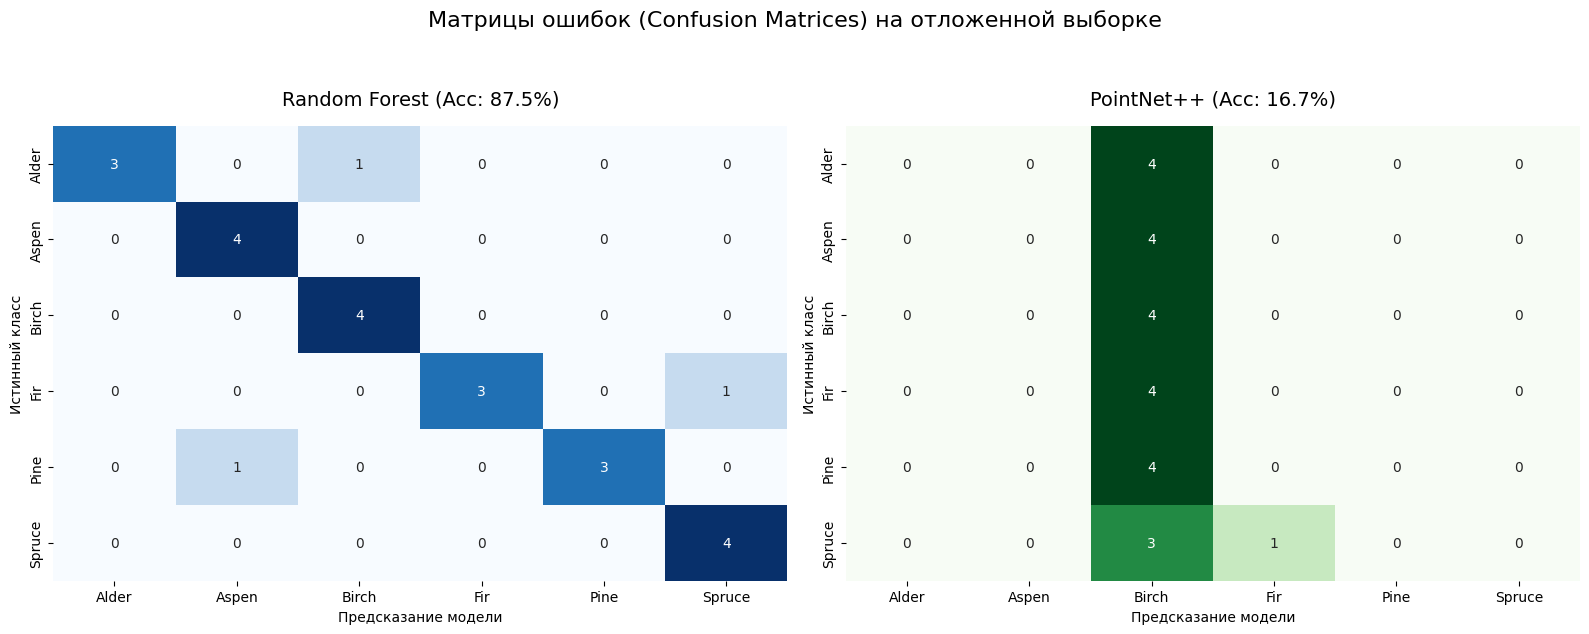

In [19]:
y_true = []
rf_features_list = []
pn_data_list = []
processed_files = 0

# Проходим по всем папкам в Holdout
for class_idx, class_name in enumerate(class_names):
    test_folder = os.path.join(HOLDOUT_DIR, class_name)
    if not os.path.exists(test_folder): continue

    las_files = list(set(glob.glob(os.path.join(test_folder, "*.las")) + glob.glob(os.path.join(test_folder, "*.LAS"))))
    
    for filepath in las_files:
        points = process_point_cloud(filepath)
        if points is None: continue
            
        # Сохраняем истинный класс
        y_true.append(class_idx)
        
        # Данные для Random Forest
        rf_features_list.append(extract_features_from_cloud(points))
        
        # Данные для PointNet++
        pos_tensor = torch.tensor(points, dtype=torch.float)
        pn_data_list.append(Data(pos=pos_tensor))
        
        processed_files += 1

# Предсказание RANDOM FOREST
X_test_holdout = np.array(rf_features_list)
y_pred_rf = rf_model.predict(X_test_holdout)

# Предсказание POINTNET++
pn_batch = Batch.from_data_list(pn_data_list).to(device)
pn_model.eval()
with torch.no_grad():
    out_pn = pn_model(pn_batch)
    y_pred_pn = out_pn.argmax(dim=1).cpu().numpy()

# Расчёт и вывод метрик
acc_rf = accuracy_score(y_true, y_pred_rf)
acc_pn = accuracy_score(y_true, y_pred_pn)

print("="*60)
print(f"ИТОГОВАЯ ТОЧНОСТЬ (ACCURACY) НА НОВЫХ ДАННЫХ:")
print(f"Random Forest: {acc_rf * 100:.2f}%")
print(f"PointNet++:    {acc_pn * 100:.2f}%")
print("="*60 + "\n")

print("--- ДЕТАЛЬНЫЙ ОТЧЕТ RANDOM FOREST ---")
print(classification_report(y_true, y_pred_rf, target_names=class_names, zero_division=0)) 

print("\n" + "-"*40 + "\n")

print("--- ДЕТАЛЬНЫЙ ОТЧЕТ POINTNET++ ---")
print(classification_report(y_true, y_pred_pn, target_names=class_names, zero_division=0))

# Матрицы ошибок
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Матрицы ошибок (Confusion Matrices) на отложенной выборке', fontsize=16, y=1.05)

# Настройки для графиков
cm_rf = confusion_matrix(y_true, y_pred_rf)
cm_pn = confusion_matrix(y_true, y_pred_pn)

# Random Forest
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=class_names, yticklabels=class_names, cbar=False)
axes[0].set_title(f'Random Forest (Acc: {acc_rf*100:.1f}%)', fontsize=14, pad=15)
axes[0].set_xlabel('Предсказание модели')
axes[0].set_ylabel('Истинный класс')

# PointNet++
sns.heatmap(cm_pn, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=class_names, yticklabels=class_names, cbar=False)
axes[1].set_title(f'PointNet++ (Acc: {acc_pn*100:.1f}%)', fontsize=14, pad=15)
axes[1].set_xlabel('Предсказание модели')
axes[1].set_ylabel('Истинный класс')

plt.tight_layout()
plt.show()

In [16]:
feature_names = [
    "Относит. Высота (Z)", 
    "Ширина кроны (X)", 
    "Ширина кроны (Y)", 
    "Дисперсия по X", 
    "Дисперсия по Y", 
    "Дисперсия по Z",
    "Перцентиль Z 10%", 
    "Перцентиль Z 25%", 
    "Перцентиль Z 50% (Медиана)", 
    "Перцентиль Z 75%", 
    "Перцентиль Z 90%",
    "Плотность: Нижняя треть", 
    "Плотность: Средняя треть", 
    "Плотность: Верхняя треть",
    "PCA (1 гл. компонента)", 
    "PCA (2 гл. компонента)", 
    "PCA (3 гл. компонента)"
]

importances = rf_model.feature_importances_

indices = np.argsort(importances)[::-1]
sorted_names = [feature_names[i] for i in indices]
sorted_importances = importances[indices]

fig, ax1 = plt.subplots(figsize=(12, 8))
sns.barplot(x=sorted_importances, y=sorted_names, palette="viridis", ax=ax1)

ax1.set_title("Важность геометрических признаков для модели Random Forest", fontsize=15, pad=15)
ax1.set_xlabel("Относительная важность (вклад признака)", fontsize=12)
ax1.set_ylabel("Название признака", fontsize=12)

for i, v in enumerate(sorted_importances):
    ax1.text(v + 0.002, i + 0.1, f"{v:.3f}", color='black', fontsize=10)

plt.tight_layout()
plt.show()

rf_precision = precision_score(y_true, y_pred_rf, average='macro', zero_division=0)
rf_recall = recall_score(y_true, y_pred_rf, average='macro', zero_division=0)
rf_f1 = f1_score(y_true, y_pred_rf, average='macro', zero_division=0)

pn_precision = precision_score(y_true, y_pred_pn, average='macro', zero_division=0)
pn_recall = recall_score(y_true, y_pred_pn, average='macro', zero_division=0)
pn_f1 = f1_score(y_true, y_pred_pn, average='macro', zero_division=0)

metrics_labels = ['Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1-Score (Macro)']
rf_scores = [acc_rf * 100, rf_precision * 100, rf_recall * 100, rf_f1 * 100]
pn_scores = [acc_pn * 100, pn_precision * 100, pn_recall * 100, pn_f1 * 100]

x = np.arange(len(metrics_labels))
width = 0.35

fig, ax2 = plt.subplots(figsize=(10, 6))
rects1 = ax2.bar(x - width/2, rf_scores, width, label='Random Forest', color='#4C72B0')
rects2 = ax2.bar(x + width/2, pn_scores, width, label='PointNet++', color='#55A868')

ax2.set_ylabel('Значение метрики (%)', fontsize=12)
ax2.set_title('Сравнение эффективности моделей на отложенной выборке (Holdout)', fontsize=15, pad=15)
ax2.set_xticks(x)
ax2.set_xticklabels(metrics_labels, fontsize=11)
ax2.set_ylim(0, 110)
ax2.legend(fontsize=12, loc='lower left')

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax2.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

IndexError: list index out of range

ЗАПУСК ТЕСТИРОВАНИЯ (Итераций: 10)
Сбор списка файлов из Holdout...
Найдено деревьев для теста: 24. Всего будет сделано 240 предсказаний.

Выполнено итераций: 1 / 10 ...
Выполнено итераций: 10 / 10 ...

ТЕСТ ЗАВЕРШЕН!

ОБЪЕКТИВНАЯ ИТОГОВАЯ ТОЧНОСТЬ (240 тестов):
Random Forest: 92.92%
PointNet++:    15.83%
--- ОТЧЕТ RANDOM FOREST ---
              precision    recall  f1-score   support

       Alder       1.00      0.97      0.99        40
       Aspen       0.82      1.00      0.90        40
       Birch       0.92      0.85      0.88        40
         Fir       1.00      0.88      0.93        40
        Pine       1.00      0.88      0.93        40
      Spruce       0.89      1.00      0.94        40

    accuracy                           0.93       240
   macro avg       0.94      0.93      0.93       240
weighted avg       0.94      0.93      0.93       240

--- ОТЧЕТ POINTNET++ ---
              precision    recall  f1-score   support

       Alder       0.00      0.00      0.0

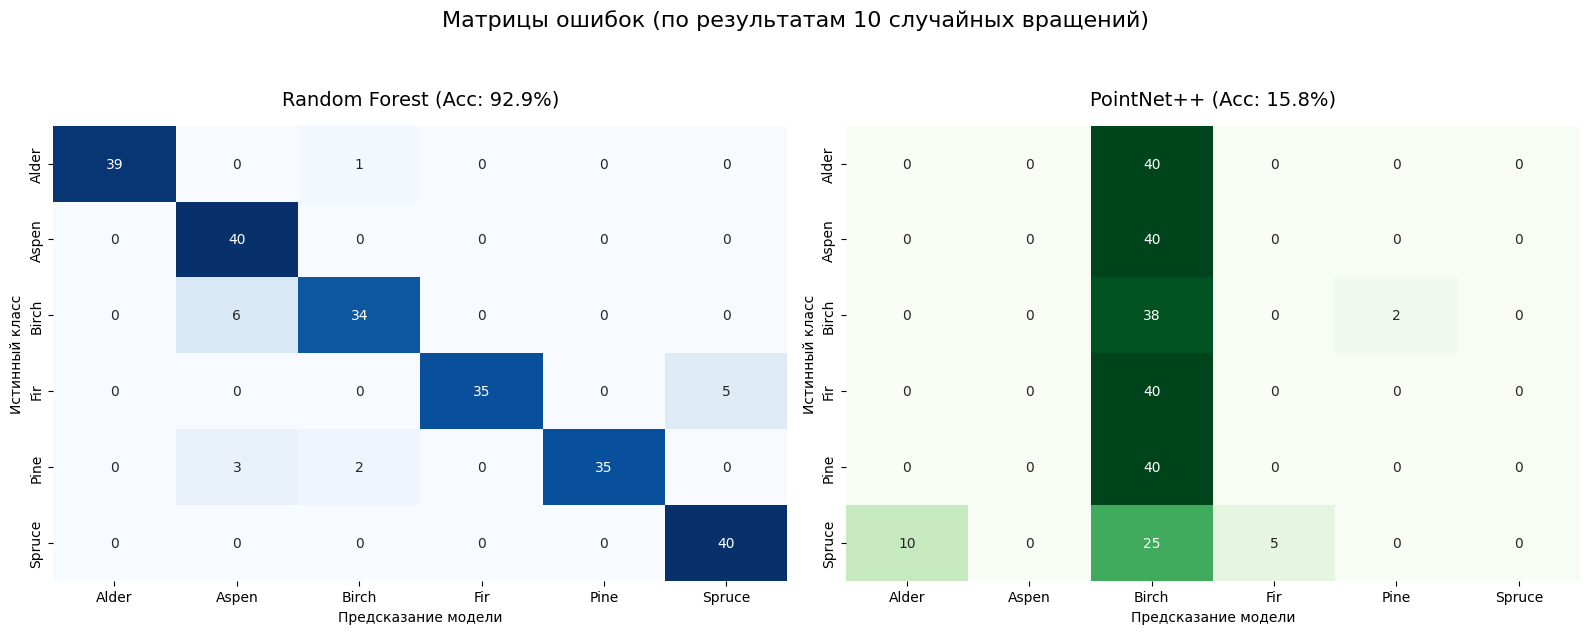

In [17]:
import os
import glob
import math
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from torch_geometric.data import Data, Batch
from IPython.display import clear_output

NUM_ITERATIONS = 10

print(f"ЗАПУСК ТЕСТИРОВАНИЯ (Итераций: {NUM_ITERATIONS})")
print("Сбор списка файлов из Holdout...")

def random_rotate_z(points):
    """Случайно поворачивает облако точек вокруг вертикальной оси Z (от 0 до 360 градусов)"""
    # Генерируем случайный угол от 0 до 2*pi радиан
    angle = np.random.uniform(0, 2 * math.pi)
    
    # Матрица поворота вокруг оси Z
    rotation_matrix = np.array([
        [math.cos(angle), -math.sin(angle), 0],
        [math.sin(angle),  math.cos(angle), 0],
        [0,                0,               1]
    ])
    
    # Умножаем координаты на матрицу поворота
    rotated_points = np.dot(points, rotation_matrix)
    return rotated_points.astype(np.float32)

# 1. Собираем пути к файлам отложенной выборки (ровно 24 файла)
holdout_files_info = []
for class_idx, class_name in enumerate(class_names):
    test_folder = os.path.join(HOLDOUT_DIR, class_name)
    if os.path.exists(test_folder):
        las_files = list(set(glob.glob(os.path.join(test_folder, "*.las")) + glob.glob(os.path.join(test_folder, "*.LAS"))))
        for filepath in las_files:
            holdout_files_info.append((filepath, class_idx))

total_trees = len(holdout_files_info)
print(f"Найдено деревьев для теста: {total_trees}. Всего будет сделано {total_trees * NUM_ITERATIONS} предсказаний.\n")

# Списки для хранения ВСЕХ 2400 результатов
y_true_all = []
y_pred_rf_all = []
y_pred_pn_all = []

# Переводим нейросеть в режим тестирования
pn_model.eval()

# 2. Главный цикл Монте-Карло
for iteration in range(NUM_ITERATIONS):
    # Списки для текущей итерации
    rf_features_iter = []
    pn_data_iter = []
    y_true_iter = []
    
    # Обрабатываем все 24 дерева
    for filepath, class_idx in holdout_files_info:
        # 2.1. Сэмплирование (process_point_cloud внутри использует np.random.choice без фикс. сида)
        points = process_point_cloud(filepath)
        if points is None: continue

        points = random_rotate_z(points)
        
        # 2.3. Подготовка данных для RF (извлечение 17 признаков)
        rf_features_iter.append(extract_features_from_cloud(points))
        
        # 2.4. Подготовка данных для PointNet++
        pos_tensor = torch.tensor(points, dtype=torch.float)
        pn_data_iter.append(Data(pos=pos_tensor))
        
        y_true_iter.append(class_idx)
        y_true_all.append(class_idx)
        
    # 3. Предсказания для текущей итерации
    # --- Random Forest ---
    pred_rf = rf_model.predict(np.array(rf_features_iter))
    y_pred_rf_all.extend(pred_rf)
    
    # --- PointNet++ ---
    pn_batch = Batch.from_data_list(pn_data_iter).to(device)
    with torch.no_grad():
        out_pn = pn_model(pn_batch)
        pred_pn = out_pn.argmax(dim=1).cpu().numpy()
    y_pred_pn_all.extend(pred_pn)
    
    # Красивый вывод прогресса (каждые 10 итераций)
    if (iteration + 1) % 10 == 0 or iteration == 0:
        print(f"Выполнено итераций: {iteration + 1} / {NUM_ITERATIONS} ...")

print("\nТЕСТ ЗАВЕРШЕН!\n")

# =====================================================================
# РАСЧЕТ И ВЫВОД ФИНАЛЬНЫХ ОБЪЕКТИВНЫХ МЕТРИК
# =====================================================================
acc_rf = accuracy_score(y_true_all, y_pred_rf_all)
acc_pn = accuracy_score(y_true_all, y_pred_pn_all)

print(f"ОБЪЕКТИВНАЯ ИТОГОВАЯ ТОЧНОСТЬ ({total_trees * NUM_ITERATIONS} тестов):")
print(f"Random Forest: {acc_rf * 100:.2f}%")
print(f"PointNet++:    {acc_pn * 100:.2f}%")

print("--- ОТЧЕТ RANDOM FOREST ---")
print(classification_report(y_true_all, y_pred_rf_all, target_names=class_names, zero_division=0)) 

print("--- ОТЧЕТ POINTNET++ ---")
print(classification_report(y_true_all, y_pred_pn_all, target_names=class_names, zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'Матрицы ошибок (по результатам {NUM_ITERATIONS} случайных вращений)', fontsize=16, y=1.05)

cm_rf = confusion_matrix(y_true_all, y_pred_rf_all)
cm_pn = confusion_matrix(y_true_all, y_pred_pn_all)

# Random Forest
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=class_names, yticklabels=class_names, cbar=False)
axes[0].set_title(f'Random Forest (Acc: {acc_rf*100:.1f}%)', fontsize=14, pad=15)
axes[0].set_xlabel('Предсказание модели')
axes[0].set_ylabel('Истинный класс')

# PointNet++
sns.heatmap(cm_pn, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=class_names, yticklabels=class_names, cbar=False)
axes[1].set_title(f'PointNet++ (Acc: {acc_pn*100:.1f}%)', fontsize=14, pad=15)
axes[1].set_xlabel('Предсказание модели')
axes[1].set_ylabel('Истинный класс')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Проверка, был ли запущен стресс-тест
if 'y_true_all' not in locals():
    print("❌ Ошибка: Сначала запустите ячейку со стресс-тестированием (Монте-Карло)!")
else:
    # 1. Вычисляем макро-усредненные метрики для Random Forest по итогам 2400 тестов
    rf_acc = accuracy_score(y_true_all, y_pred_rf_all)
    rf_precision = precision_score(y_true_all, y_pred_rf_all, average='macro', zero_division=0)
    rf_recall = recall_score(y_true_all, y_pred_rf_all, average='macro', zero_division=0)
    rf_f1 = f1_score(y_true_all, y_pred_rf_all, average='macro', zero_division=0)

    # 2. Вычисляем макро-усредненные метрики для PointNet++ по итогам 2400 тестов
    pn_acc = accuracy_score(y_true_all, y_pred_pn_all)
    pn_precision = precision_score(y_true_all, y_pred_pn_all, average='macro', zero_division=0)
    pn_recall = recall_score(y_true_all, y_pred_pn_all, average='macro', zero_division=0)
    pn_f1 = f1_score(y_true_all, y_pred_pn_all, average='macro', zero_division=0)

    # 3. Подготовка данных для графика
    metrics_labels = ['Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1-Score (Macro)']
    rf_scores = [rf_acc * 100, rf_precision * 100, rf_recall * 100, rf_f1 * 100]
    pn_scores = [pn_acc * 100, pn_precision * 100, pn_recall * 100, pn_f1 * 100]

    x = np.arange(len(metrics_labels))  # Расположение групп столбцов по оси X
    width = 0.35  # Ширина столбцов

    # 4. Отрисовка графика
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Рисуем столбцы (смещаем RF влево, а PN вправо от центра метки)
    rects1 = ax.bar(x - width/2, rf_scores, width, label='Random Forest', color='#4C72B0', edgecolor='black', linewidth=0.5)
    rects2 = ax.bar(x + width/2, pn_scores, width, label='PointNet++', color='#55A868', edgecolor='black', linewidth=0.5)

    # Настройка осей и заголовков
    ax.set_ylabel('Значение метрики (%)', fontsize=14)
    # Динамический заголовок, показывающий количество проведенных тестов
    ax.set_title(f'Объективное сравнение моделей (Стресс-тест: {len(y_true_all)} предсказаний со случайным вращением)', fontsize=15, pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_labels, fontsize=13)
    ax.set_ylim(0, 110) # Фиксируем ось Y, оставляя место для подписей сверху
    
    # Легенда
    ax.legend(fontsize=12, loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=2)

    # Функция для добавления красивых процентов прямо над столбцами
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.1f}%',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 4),  # Смещение текста на 4 пункта вверх
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=12, fontweight='bold')

    autolabel(rects1)
    autolabel(rects2)

    # Добавляем легкую сетку на фон для читаемости
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.show()

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

def generate_augmentation_plot(filepath):
    if not filepath:
        return
        
    # 1. Получаем оригинальное обработанное дерево
    original_points = process_point_cloud(filepath)
    if original_points is None:
        print("❌ Ошибка обработки файла.")
        return

    # 2. Создаем 3 искаженные копии
    versions = []
    
    # 2.1 Оригинал
    versions.append((original_points, "Оригинал\n(Без искажений)"))
    
    # 2.2 Только поворот
    # Специально берем угол от 90 до 270 градусов, чтобы поворот был хорошо заметен
    angle1 = np.random.uniform(math.pi/2, 1.5 * math.pi) 
    rot_matrix1 = np.array([
        [math.cos(angle1), -math.sin(angle1), 0],
        [math.sin(angle1),  math.cos(angle1), 0],
        [0,                0,               1]
    ])
    pts_rotated = np.dot(original_points, rot_matrix1)
    angle_deg = int(math.degrees(angle1))
    versions.append((pts_rotated, f"Поворот по оси Z\n(на {angle_deg}°)"))
    
    # 2.3 Только шум (Jittering)
    # Делаем шум чуть сильнее (0.015), чтобы его было видно на графике
    noise = np.random.normal(0, 0.015, size=original_points.shape)
    pts_noisy = original_points + noise
    versions.append((pts_noisy, "Добавлен шум\n(Имитация погрешности лидара)"))
    
    # 2.4 Полная аугментация (как при обучении)
    angle2 = np.random.uniform(0, 2 * math.pi)
    rot_matrix2 = np.array([
        [math.cos(angle2), -math.sin(angle2), 0],
        [math.sin(angle2),  math.cos(angle2), 0],
        [0,                0,               1]
    ])
    scale = 1 # Уменьшаем размер до 85%
    pts_full = (np.dot(original_points, rot_matrix2) + np.random.normal(0, 0.01, size=original_points.shape)) * scale
    versions.append((pts_full, "Полная аугментация\n(Поворот + Масштаб 85% + Шум)"))

    # 3. Отрисовка графиков 2x2
    fig = plt.figure(figsize=(14, 14)) # Квадратное большое полотно для презентации
    
    for i, (pts, title) in enumerate(versions):
        # 2 строки, 2 столбца
        ax = fig.add_subplot(2, 2, i+1, projection='3d')
        
        x, y, z = pts[:, 0], pts[:, 1], pts[:, 2]
        
        # Отрисовка с раскраской по высоте
        ax.scatter(x, y, z, c=z, cmap='jet', s=8, alpha=0.9, marker='o', edgecolors='none')
        
        # Настройка ракурса (Изометрия, чтобы было видно все изменения)
        ax.view_init(elev=15, azim=-45)
        ax.set_title(title, fontsize=16, pad=15, fontweight='bold')
        
        # Жестко фиксируем границы от -1 до 1, чтобы изменение масштаба было наглядно видно!
        ax.set_xlim([-1, 1])
        ax.set_ylim([-1, 1])
        ax.set_zlim([-1, 1])
        
        ax.axis('off') # Отключаем оси для красоты

    plt.tight_layout()
    plt.show()

# 4. Интерфейс выбора файла
dropdown_aug = widgets.Dropdown(
    options=available_files, # Используем список файлов из предыдущих ячеек
    description='Файл:',
    layout={'width': '400px'}
)

output_aug = widgets.Output()

def on_dropdown_aug_change(change):
    with output_aug:
        clear_output(wait=True)
        generate_augmentation_plot(change.new)

dropdown_aug.observe(on_dropdown_aug_change, names='value')
display(dropdown_aug, output_aug)

# Генерируем картинку для первого файла по умолчанию
with output_aug:
    generate_augmentation_plot(dropdown_aug.value)